In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from keras import datasets, layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

from imutils import paths

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, multilabel_confusion_matrix

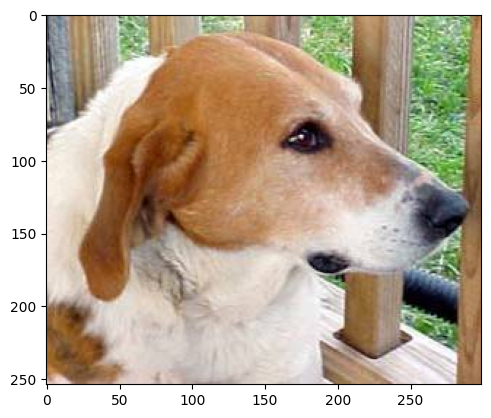

In [2]:
image_paths_200 = list(paths.list_images('./data/class_dataset/animals_200/'))

image = cv2.imread(image_paths_200[60])
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)

In [9]:
def get_data(path: str) -> tuple[list, list]:
    
	files = os.listdir(path)
 
	labels = []
	data = []

	labels = [int(filename.split('.')[0] == 'dog') for filename in files]

	for file in files:
		image = cv2.imread(os.path.join(path, file))
		resized = cv2.resize(image, (32, 32))
		data.append(resized)

	data = np.array(data)
	labels = np.array(labels)

	data = data.reshape((len(labels), 3072))
	data = data / 255.0
 
	return (labels, data)

In [10]:

(labels_200, data_200) = get_data('./data/class_dataset/animals_200/')
X_train, X_test, y_train, y_test = train_test_split(data_200, labels_200, test_size=0.2, random_state=5)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (160, 3072)
X_test shape: (40, 3072)
y_train shape: (160,)
y_test shape: (40,)


In [5]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(3072,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

optimizer = optimizers.Adam(learning_rate=0.0001)

model.compile(
    loss='binary_crossentropy',
	optimizer=optimizer,
	metrics=['accuracy']
)

callback = EarlyStopping(
    monitor='loss', 
    min_delta=0.00001,
    patience=10,
    restore_best_weights=True
)

model.summary()

2026-02-07 14:19:03.302381: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-02-07 14:19:03.302436: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-02-07 14:19:03.302452: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-02-07 14:19:03.302675: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-07 14:19:03.302876: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                196672    
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 198785 (776.50 KB)
Trainable params: 198785 (776.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
history = model.fit(
    X_train, 
    y_train,
    epochs=500,
    batch_size=128,
    callbacks=[callback],
    verbose=1
)

Epoch 1/500


2026-02-07 14:19:04.145909: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-02-07 14:19:04.189275: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


2/2 [==============================] - 2s 250ms/step - loss: 1.0715 - accuracy: 0.5000
Epoch 2/500
2/2 [==============================] - 0s 24ms/step - loss: 0.7581 - accuracy: 0.4938
Epoch 3/500
2/2 [==============================] - 0s 21ms/step - loss: 0.7584 - accuracy: 0.4938
Epoch 4/500
2/2 [==============================] - 0s 15ms/step - loss: 0.7874 - accuracy: 0.5063
Epoch 5/500
2/2 [==============================] - 0s 98ms/step - loss: 0.7599 - accuracy: 0.4938
Epoch 6/500
2/2 [==============================] - 0s 34ms/step - loss: 0.7256 - accuracy: 0.5188
Epoch 7/500
2/2 [==============================] - 0s 34ms/step - loss: 0.7131 - accuracy: 0.5250
Epoch 8/500
2/2 [==============================] - 0s 13ms/step - loss: 0.7302 - accuracy: 0.5125
Epoch 9/500
2/2 [==============================] - 0s 19ms/step - loss: 0.7538 - accuracy: 0.4875
Epoch 10/500
2/2 [==============================] - 0s 17ms/step - loss: 0.7595 - accuracy: 0.5000
Epoch 11/500
2/2 [============

2/2 [==============================] - 0s 14ms/step


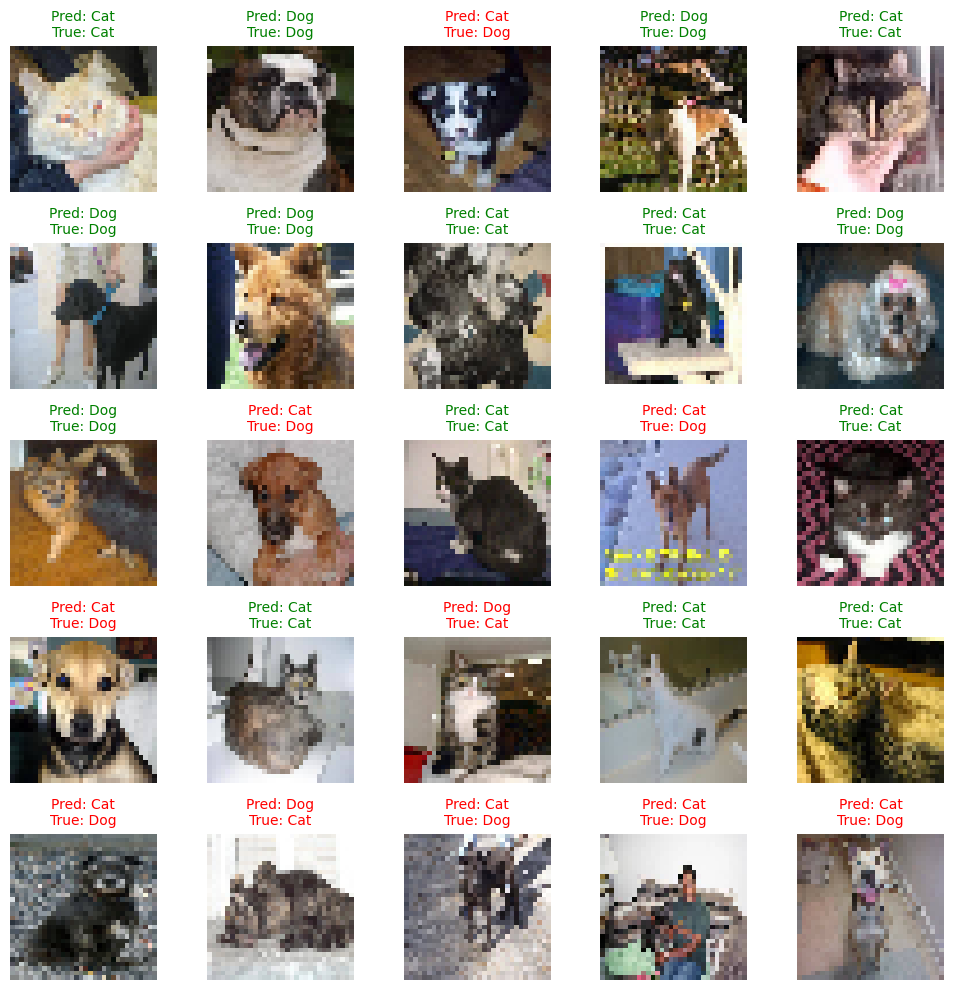

In [7]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

num_images = 25
plt.figure(figsize=(10, 10))

for i in range(num_images):
    
    ax = plt.subplot(5, 5, i + 1)
    img = X_test[i].reshape(32, 32, 3)
    img = img.astype('float32')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    
    pred_label = "Dog" if predictions[i] == 1 else "Cat"
    true_label = "Dog" if y_test[i] == 1 else "Cat"
    
    color = "green" if pred_label == true_label else "red"
    
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
(labels_1000, data_1000) = get_data('./data/class_dataset/animals_1000/')
X_train, X_test, y_train, y_test = train_test_split(data_1000, labels_1000, test_size=0.2, random_state=5)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (800, 3072)
X_test shape: (200, 3072)
y_train shape: (800,)
y_test shape: (200,)


In [12]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(3072,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

optimizer = optimizers.Adam(learning_rate=0.0001)

model.compile(
    loss='binary_crossentropy',
	optimizer=optimizer,
	metrics=['accuracy']
)

callback = EarlyStopping(
    monitor='loss', 
    min_delta=0.00001,
    patience=10,
    restore_best_weights=True
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                196672    
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 198785 (776.50 KB)
Trainable params: 198785 (776.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
history = model.fit(
    X_train, 
    y_train,
    epochs=500,
    batch_size=128,
    callbacks=[callback],
    verbose=1
)

Epoch 1/500


2026-02-07 14:22:12.025296: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


7/7 [==============================] - 1s 28ms/step - loss: 0.7496 - accuracy: 0.4725
Epoch 2/500
7/7 [==============================] - 0s 6ms/step - loss: 0.7158 - accuracy: 0.5050
Epoch 3/500
7/7 [==============================] - 0s 8ms/step - loss: 0.7123 - accuracy: 0.5150
Epoch 4/500
7/7 [==============================] - 0s 7ms/step - loss: 0.7112 - accuracy: 0.5063
Epoch 5/500
7/7 [==============================] - 0s 7ms/step - loss: 0.7053 - accuracy: 0.5325
Epoch 6/500
7/7 [==============================] - 0s 6ms/step - loss: 0.7061 - accuracy: 0.5175
Epoch 7/500
7/7 [==============================] - 0s 7ms/step - loss: 0.7004 - accuracy: 0.5337
Epoch 8/500
7/7 [==============================] - 0s 6ms/step - loss: 0.7031 - accuracy: 0.5125
Epoch 9/500
7/7 [==============================] - 0s 7ms/step - loss: 0.6988 - accuracy: 0.5362
Epoch 10/500
7/7 [==============================] - 0s 7ms/step - loss: 0.6938 - accuracy: 0.5375
Epoch 11/500
7/7 [======================

7/7 [==============================] - 0s 8ms/step


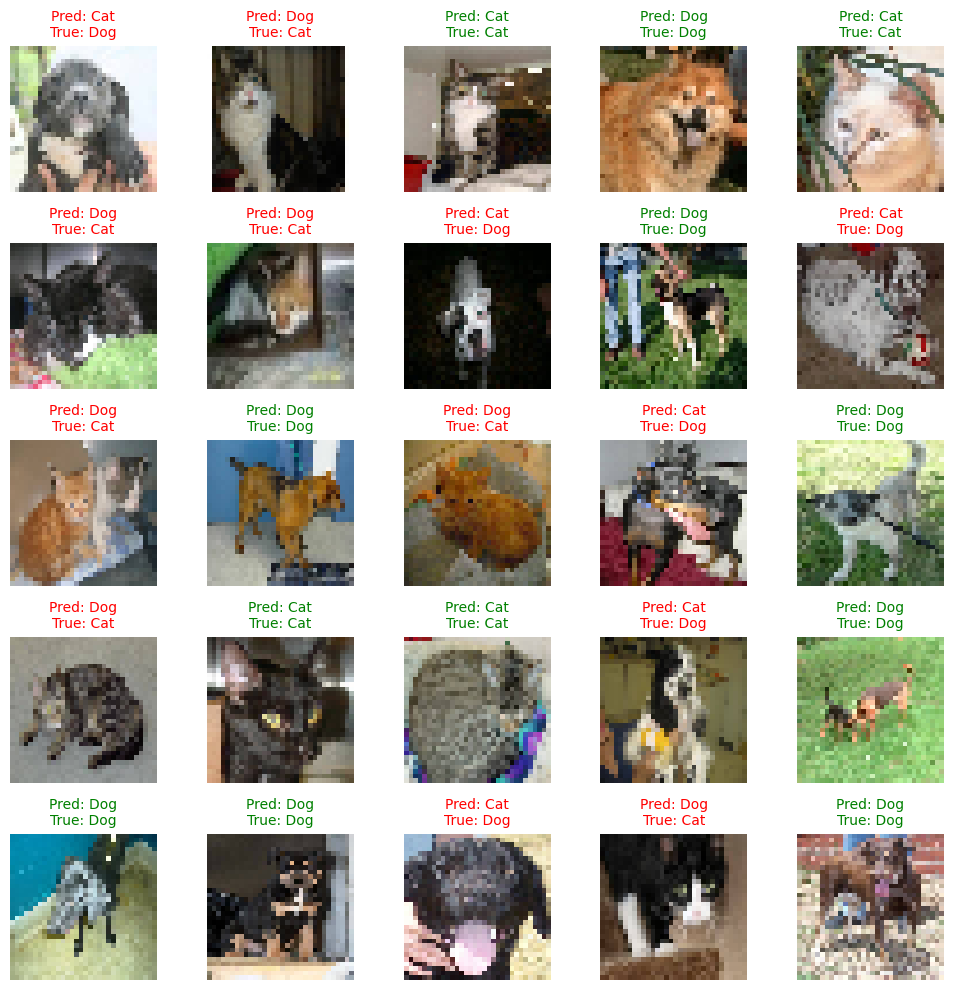

In [14]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

num_images = 25
plt.figure(figsize=(10, 10))

for i in range(num_images):
    
    ax = plt.subplot(5, 5, i + 1)
    img = X_test[i].reshape(32, 32, 3)
    img = img.astype('float32')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    
    pred_label = "Dog" if predictions[i] == 1 else "Cat"
    true_label = "Dog" if y_test[i] == 1 else "Cat"
    
    color = "green" if pred_label == true_label else "red"
    
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()